# GNSS-INS Point Cloud Processing Assignment

## Overview
This notebook processes sensor data from a vehicle equipped with:
- Top lidar
- GNSS-INS system
- Cameras

All sensors are calibrated, time-synchronized, and supported by RTK correction data.

## Tasks
1. **Point Cloud Aggregation** (8 points) - Aggregate frame-by-frame lidar data using calibration and ego-motion data
2. **Moving Object Filtering** (9 points) - Identify and remove moving objects from the aggregated point cloud
3. **Point Cloud Colorization** (8 points) - Assign color values to points using camera image data




Student Name: Rihab Laroussi

Student ID: XMHGAU

## Setup and Imports

**Note:** If you encounter import errors, run the installation cell below first.


In [ ]:
# Install required packages

# !pip install nuscenes-devkit
# !pip install open3d
# !pip install pyquaternion


In [1]:
# Import necessary libraries
import numpy as np
import open3d as o3d
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud, Box
from nuscenes.utils.geometry_utils import transform_matrix, points_in_box, Quaternion
from PIL import Image
import matplotlib.pyplot as plt


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Camera Views from All Sensors

This section displays the camera images from all sensors to show what the vehicle's cameras are capturing. This helps understand the multi-view setup before processing the point cloud data.


In [17]:
from nuscenes.nuscenes import NuScenes

# Initialize NuScenes
nusc = NuScenes(version='v1.0-mini', dataroot='/home/riri/Documents/ELTE/3D sensing/GNSS', verbose=False)

# List all scenes
print("Available scenes in v1.0-mini:")
print("-" * 50)
for i, scene in enumerate(nusc.scene):
    print(f"{i+1}. {scene['name']} - Token: {scene['token'][:8]}...")
    print(f"   Description: {scene['description']}")
    print(f"   Number of samples: {scene['nbr_samples']}")
    print()

Available scenes in v1.0-mini:
--------------------------------------------------
1. scene-0061 - Token: cc8c0bf5...
   Description: Parked truck, construction, intersection, turn left, following a van
   Number of samples: 39

2. scene-0103 - Token: fcbccedd...
   Description: Many peds right, wait for turning car, long bike rack left, cyclist
   Number of samples: 40

3. scene-0553 - Token: 6f83169d...
   Description: Wait at intersection, bicycle, large truck, peds crossing crosswalk, ped with stroller
   Number of samples: 41

4. scene-0655 - Token: bebf5f5b...
   Description: Parking lot, parked cars, jaywalker, bendy bus, gardening vehicles
   Number of samples: 41

5. scene-0757 - Token: 2fc37537...
   Description: Arrive at busy intersection, bus, wait at intersection, bicycle, peds
   Number of samples: 41

6. scene-0796 - Token: c5224b9b...
   Description: Scooter, peds on sidewalk, bus, cars, truck, fake construction worker, bicycle, cross intersection, car overtaking us
   

Scene: scene-0103
Sample token: 3e8750f3...
Number of cameras: 6
Camera channels: CAM_BACK, CAM_BACK_LEFT, CAM_BACK_RIGHT, CAM_FRONT, CAM_FRONT_LEFT, CAM_FRONT_RIGHT



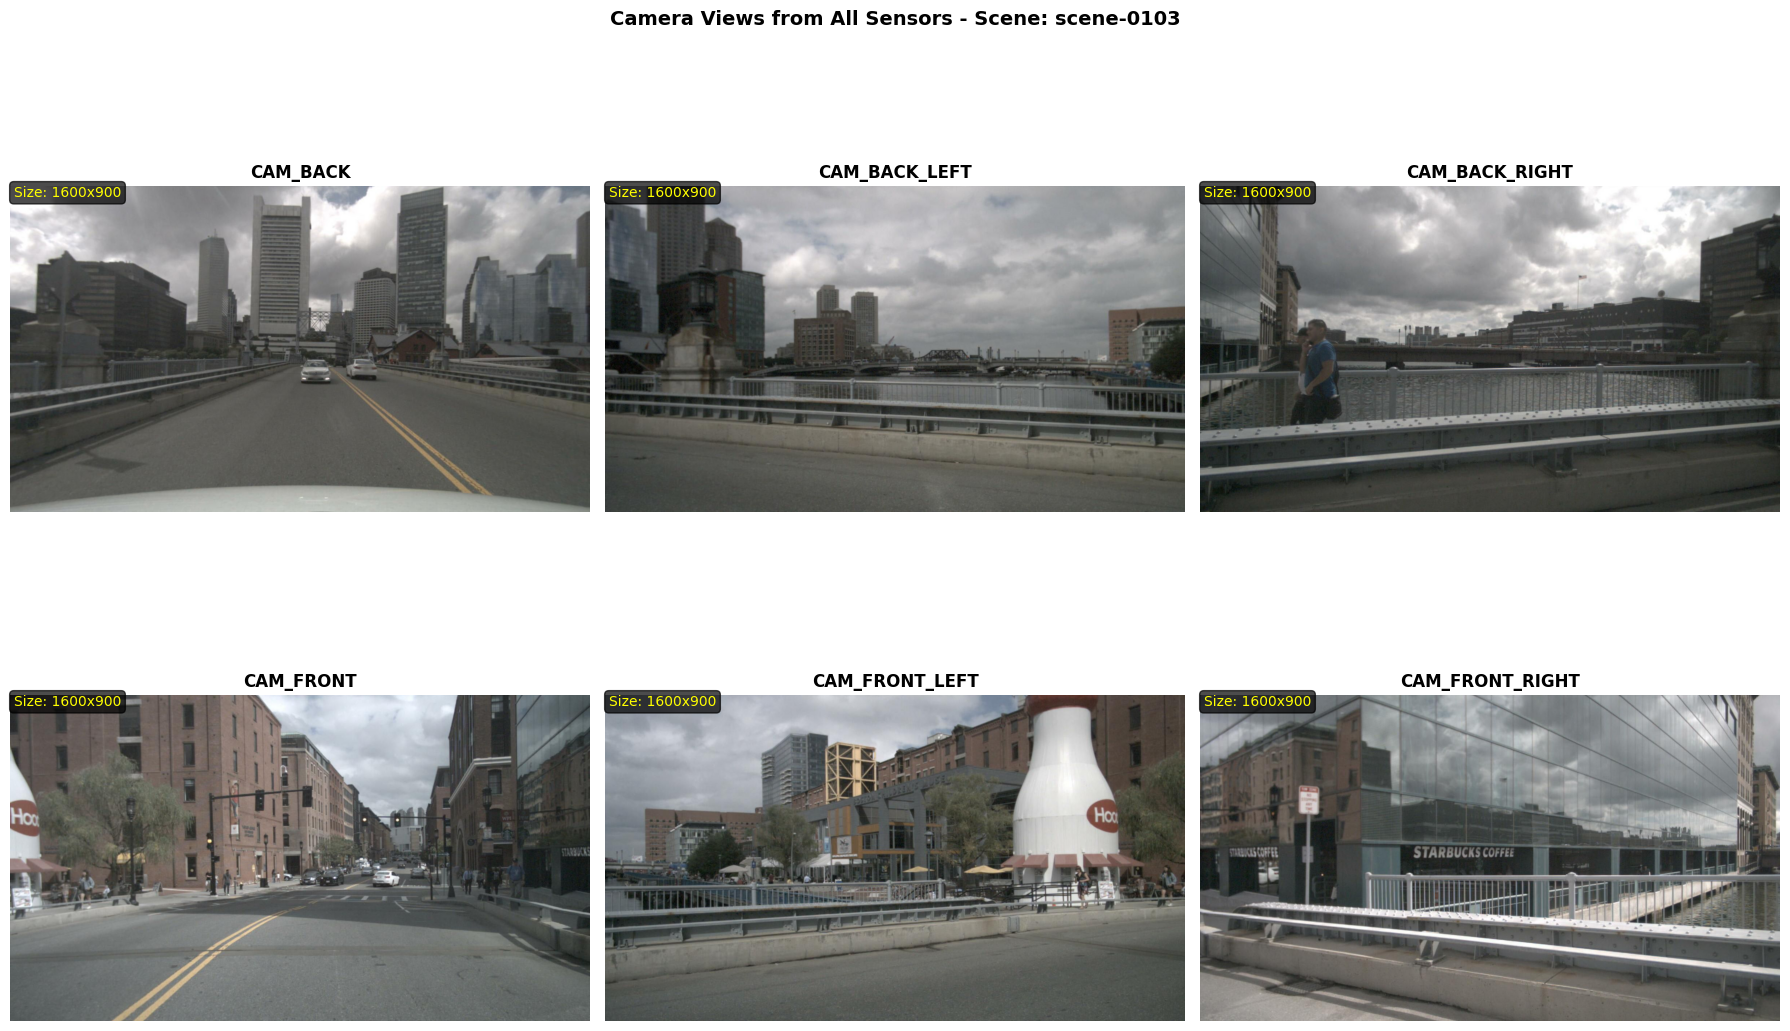


Displayed 6 camera views from the first sample.


In [25]:
# Display Camera Views from All Sensors

# Initialize NuScenes dataset
nusc = NuScenes(version='v1.0-mini', dataroot='/home/riri/Documents/ELTE/3D sensing/GNSS', verbose=False)

# Get the target scene
scene_name = 'scene-0103'
scene = next(scene for scene in nusc.scene if scene['name'] == scene_name)

# Get the first sample to display
sample_token = scene['first_sample_token']
sample = nusc.get('sample', sample_token)

# Get all camera channels
camera_channels = [key for key in sample['data'].keys() if 'CAM' in key]
camera_channels.sort()  # Sort for consistent display order

print(f"Scene: {scene_name}")
print(f"Sample token: {sample_token[:8]}...")
print(f"Number of cameras: {len(camera_channels)}")
print(f"Camera channels: {', '.join(camera_channels)}\n")

# Create a figure to display all camera views
# Arrange in a 2x3 grid for 6 cameras
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Display each camera image
for idx, camera_channel in enumerate(camera_channels):
    # Get camera data
    camera_token = sample['data'][camera_channel]
    camera_data = nusc.get('sample_data', camera_token)
    
    # Load image
    image_path = nusc.get_sample_data_path(camera_token)
    image = Image.open(image_path)
    image_array = np.array(image)
    
    # Display image
    axes[idx].imshow(image_array)
    axes[idx].set_title(f'{camera_channel}', fontsize=12, fontweight='bold')
    axes[idx].axis('off')
    
    # Add image info
    axes[idx].text(10, 30, f'Size: {image_array.shape[1]}x{image_array.shape[0]}', 
                  color='yellow', fontsize=10, 
                  bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# Hide unused subplots if there are fewer than 6 cameras
for idx in range(len(camera_channels), 6):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle(f'Camera Views from All Sensors - Scene: {scene_name}', 
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

print(f"\nDisplayed {len(camera_channels)} camera views from the first sample.")


## Task 1: Point Cloud Aggregation (8 points)

Using the provided calibration and ego-motion data from GNSS-INS, aggregate frame-by-frame lidar point data to create a comprehensive virtual point cloud representation of the environment along the vehicle's trajectory.

### Step-by-Step Process:

**Step 1: Initialize the Scene**
- Identify the target scene by its name in the NuScenes dataset
- Retrieve the first sample token from the scene to start processing frames sequentially

**Step 2: Iterate Through Frames**
- Use the sample['next'] token to move through all frames in the scene
- For each frame, retrieve the LiDAR data token (LIDAR_TOP) and load the raw point cloud

**Step 3: Transform Points to Global Coordinates**
- Retrieve sensor calibration data to compute transformation from sensor's local frame to ego (vehicle) frame
- Retrieve ego pose data to compute transformation from ego frame to global coordinate frame
- Combine both transformations and apply to LiDAR points

**Step 4: Aggregate Transformed Points**
- Convert transformed points into an Open3D PointCloud object
- Add points to an aggregated point cloud initialized at the start
- Repeat for all frames until the end of the scene is reached

**Step 5: Save and Visualize**
- Save the aggregated point cloud as a .pcd file
- Visualize the aggregated point cloud using Open3D's visualization tools


In [ ]:
# build a global map:
# take each lidar frame in the chosen scene, transforms it into a shared global coordinate system and stacks all frames together
# ego represents the vehicle's position and orientation in the global map from GNSS-INS data X,Y,Z


In [36]:
# Task 1: Point Cloud Aggregation

# Step 1: Initialize the Scene
# Initialize NuScenes dataset object with the mini dataset version
nusc = NuScenes(version='v1.0-mini', dataroot='/home/riri/Documents/ELTE/3D sensing/GNSS', verbose=True)

# Specify the target scene name
scene_name = 'scene-0103'

# Get the scene object by name
scene = next(scene for scene in nusc.scene if scene['name'] == scene_name)

# Retrieve the first sample token from the scene to start processing
sample_token = scene['first_sample_token']

# Initialize global point cloud
global_cloud = o3d.geometry.PointCloud()

# Step 2: Iterate Through Frames
frame_count = 0

# Loop through all frames in the scene using the 'next' token
while sample_token:
    # Get the current sample data
    sample = nusc.get('sample', sample_token)
    
    # Retrieve the LiDAR data token for LIDAR_TOP sensor
    lidar_token = sample['data']['LIDAR_TOP']
    lidar_data = nusc.get('sample_data', lidar_token)
    
    # Load the raw point cloud from the .bin file
    lidar_pc = LidarPointCloud.from_file(nusc.get_sample_data_path(lidar_token))
    
    # Step 3: Transform Points to Global Coordinates
    # Get sensor calibration data (transformation from sensor frame to ego frame)
    calibrated_sensor = nusc.get('calibrated_sensor', lidar_data['calibrated_sensor_token'])
    
    # Get ego pose data (transformation from ego frame to global frame)
    ego_pose = nusc.get('ego_pose', lidar_data['ego_pose_token'])
    
    # Compute transformations using transform_matrix utility function
    sensor_to_ego = transform_matrix(
        calibrated_sensor['translation'], 
        Quaternion(calibrated_sensor['rotation']), 
        inverse=False
    )
    ego_to_global = transform_matrix(
        ego_pose['translation'], 
        Quaternion(ego_pose['rotation']), 
        inverse=False
    )
    
    # Combine transformations: sensor -> ego -> global
    sensor_to_global = ego_to_global @ sensor_to_ego
    
    # Apply transformation to LiDAR points
    lidar_pc.transform(sensor_to_global)
    
    # Step 4: Aggregate Transformed Points
    # Extract x, y, z coordinates (first 3 rows of the point cloud)
    points_xyz = lidar_pc.points[:3, :].T  # Transpose to get Nx3 array
    
    # Convert to Open3D point cloud and add to the global cloud
    lidar_cloud = o3d.geometry.PointCloud()
    lidar_cloud.points = o3d.utility.Vector3dVector(points_xyz)
    global_cloud += lidar_cloud
    
    # Move to the next frame using the 'next' token
    sample_token = sample['next'] if sample['next'] else None
    frame_count += 1
    
    # Print progress every 10 frames
    if frame_count % 10 == 0:
        print(f"Processed {frame_count} frames...")

print(f"\nTotal frames processed: {frame_count}")
print(f"Total points aggregated: {len(global_cloud.points)}")

# Step 5: Save and Visualize
# Save the aggregated point cloud as a .pcd file
output_path = 'aggregated_pointcloud.pcd'
o3d.io.write_point_cloud(output_path, global_cloud)
print(f"\nAggregated point cloud saved to: {output_path}")

# Visualize the aggregated point cloud
def visualize_point_cloud(point_cloud, window_title="Point Cloud Visualization"):
    """
    Visualize a point cloud using Open3D.
    """
    vis = o3d.visualization.Visualizer()
    vis.create_window(window_name=window_title)
    
    # Configure rendering settings
    render_option = vis.get_render_option()
    render_option.point_size = 1.0
    
    vis.add_geometry(point_cloud)
    vis.run()
    vis.destroy_window()

# Visualize the point cloud
visualize_point_cloud(global_cloud, window_title="Aggregated Point Cloud")


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.470 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Processed 10 frames...
Processed 20 frames...
Processed 30 frames...
Processed 40 frames...

Total frames processed: 40
Total points aggregated: 1388928

Aggregated point cloud saved to: aggregated_pointcloud.pcd


## Task 2: Moving Object Filtering (9 points)

From the aggregated virtual point cloud, identify and remove data corresponding to moving objects to create a static representation of the environment.

**Note:** Manual annotation data is not allowed to use.

### Step-by-Step Process:

**Step 1: Compute Object Velocity**
- For each annotation, calculate the velocity of the object using its current and previous positions
- Retrieve the current and previous translations from the annotation metadata
- Calculate the displacement between the two positions
- Compute the velocity by dividing the displacement by the time difference between the two frames
- Return zero velocity if there is no previous annotation

**Step 2: Filter Moving and Static Points**
- Initialize boolean masks for moving and static points in the point cloud
- For each annotation, retrieve the velocity of the object
- Create a bounding box for the object using its translation, size, and rotation
- Identify points within the bounding box and exclude ground points
- Mark points as moving if the object's velocity exceeds the velocity threshold
- Mark points as static otherwise

**Step 3: Separate Moving and Static Clouds**
- Extract points from the aggregated cloud based on the masks
- Convert these points into Open3D PointCloud objects and assign distinct colors for visualization
- Moving points: Red
- Static points: Cyan

**Step 4: Save and Visualize the Results**
- Save the static and moving point clouds as .pcd files
- Combine the two clouds and visualize them interactively using Open3D


In [ ]:
# load the aggregated point cloud from task 1 and convert it to numpy array
# a sample is a one keyframe in a scene , it stores the link to where the data lives of all sensors
# In practice, a sample dict contains:
# timestamp: time of that sample (microseconds).
# data: a dict mapping each sensor channel to a sample_data token, e.g.
# sample['data']['LIDAR_TOP'] → token for the LiDAR frame file
# sample['data']['CAM_FRONT'], … → tokens for camera image files
# anns: list of sample_annotation tokens (3D labeled boxes for objects at that time).
# prev / next: tokens to the previous/next sample in the scene (how you iterate through frames).
# scene_token: which scene this sample belongs to.

# for each sample, take all the annotations
# for each annotation, take its translation and timestamp 
# look for the previous annotation for the same object in the previous frame , and get its translation and timestamp
# Speed = || Delta translation|| / Delta time 
# if v > 0.25 m/s, the object is moving, otherwise it is static
# apply it as label to the lidar points inside the bounding box of the annotation, excluding the ground points


In [ ]:
# Task 2: Moving Object Filtering

# Load the aggregated point cloud from Task 1
aggregated_pcd = o3d.io.read_point_cloud('aggregated_pointcloud.pcd')
aggregated_points = np.asarray(aggregated_pcd.points)
print(f"Loaded aggregated point cloud with {len(aggregated_points)} points")

# Initialize NuScenes dataset (if not already initialized)
# Note: Make sure to use the same scene as in Task 1
nusc = NuScenes(version='v1.0-mini', dataroot='/home/riri/Documents/ELTE/3D sensing/GNSS', verbose=False)
scene_name = 'scene-0103'
scene = next(scene for scene in nusc.scene if scene['name'] == scene_name)

# Step 1: Compute Object Velocity
# Define velocity threshold (in m/s) to distinguish moving objects from static ones
velocity_threshold = 0.25  # Objects moving faster than 0.25 m/s are considered moving

# the annotation dict contains the following keys:
# 'translation': list of 3 floats, representing the object's position in meters
# 'size': list of 3 floats, representing the object's dimensions in meters
# 'rotation': list of 4 floats, representing the object's rotation in quaternion format
# 'prev': string, representing the token of the previous annotation for the same object
# 'sample_token': string, representing the token of the sample that contains the annotation


def compute_velocity(annotation, nusc):
    """
    Calculate the velocity of an object from its annotation data.
    Returns scalar velocity magnitude in m/s.
    """
    if annotation.get('prev'):
        try:
            # Calculate velocity using previous annotation
            current_translation = np.array(annotation['translation'])
            current_sample = nusc.get('sample', annotation['sample_token'])
            current_timestamp = current_sample['timestamp']
            
            prev_ann = nusc.get('sample_annotation', annotation['prev'])
            prev_translation = np.array(prev_ann['translation'])
            prev_sample = nusc.get('sample', prev_ann['sample_token'])
            prev_timestamp = prev_sample['timestamp']
            
            displacement = current_translation - prev_translation
            time_delta = (current_timestamp - prev_timestamp) / 1e6  # Convert from microseconds to seconds
            return np.linalg.norm(displacement) / time_delta
        except KeyError as e:
            print(f"KeyError in compute_velocity: {e}")
            return 0.0
    return 0.0  # Return zero if no previous annotation exists

# Step 2: Filter Moving and Static Points
# Initialize boolean masks for moving and static points
num_points = len(aggregated_points)
moving_mask = np.zeros(num_points, dtype=bool)  # Initialize all as non-moving
static_mask = np.ones(num_points, dtype=bool)   # Initialize all as static

# Ground points mask based on height threshold 
ground_threshold = 0.3  # Height threshold for ground points
ground_mask = aggregated_points[:, 2] < ground_threshold  # Identify ground points (z < ground_threshold)

print(f"Ground height threshold: {ground_threshold:.2f} m")
print(f"Number of ground points: {np.sum(ground_mask)}")

# Iterate through all samples in the scene to get annotations
sample_token = scene['first_sample_token']
sample_count = 0

# Collect all annotations from all frames
all_annotations = []

while sample_token:
    sample = nusc.get('sample', sample_token)
    
    # Get all annotations for this sample
    for ann_token in sample['anns']:
        all_annotations.append(nusc.get('sample_annotation', ann_token))
    
    sample_token = sample['next'] if sample['next'] else None
    sample_count += 1

print(f"Processing {len(all_annotations)} annotations from {sample_count} samples...")

# Process each annotation to filter points
for annotation in all_annotations:
    # Skip invalid annotations
    if not ('translation' in annotation and 'size' in annotation and 'rotation' in annotation):
        print(f"Skipping invalid annotation: {annotation}")
        continue
    
    # Retrieve the velocity of the object (scalar magnitude)
    velocity = compute_velocity(annotation, nusc)
    
    # Create a bounding box for the object using its translation, size, and rotation
    box = Box(
        annotation['translation'],
        annotation['size'],
        Quaternion(annotation['rotation'])   # this is to find which lidar points belong to this object
    )
    
    # Get points inside the bounding box using utility function
    points_in_bbox = points_in_box(box, aggregated_points.T)
    
    # Exclude ground points from consideration, we dont want to consider the ground as moving
    points_in_bbox = points_in_bbox & ~ground_mask
    
    # Mark points as moving if the object's velocity exceeds the velocity threshold
    if velocity > velocity_threshold:
        moving_mask[points_in_bbox] = True
    else:
        static_mask[points_in_bbox] = False

print(f"\nFiltering results:")
print(f"Moving points: {np.sum(moving_mask)}")
print(f"Static points: {np.sum(static_mask)}")
print(f"Unclassified points: {num_points - np.sum(moving_mask) - np.sum(static_mask)}")

# Step 3: Separate Moving and Static Clouds
# Extract points from the aggregated cloud based on the masks
# Ensure static points exclude moving points to prevent overlap
moving_points = aggregated_points[moving_mask]
static_points = aggregated_points[static_mask]

# Convert these points into Open3D PointCloud objects
moving_pcd = o3d.geometry.PointCloud()
moving_pcd.points = o3d.utility.Vector3dVector(moving_points)
moving_pcd.paint_uniform_color([0, 1, 0])  # Green for moving

static_pcd = o3d.geometry.PointCloud()
static_pcd.points = o3d.utility.Vector3dVector(static_points)
static_pcd.paint_uniform_color([0.9, 0.75, 1.0])

print(f"\nCreated point clouds:")
print(f"Moving cloud: {len(moving_points)} points (Red)")
print(f"Static cloud: {len(static_points)} points (Cyan)")

# Step 4: Save and Visualize the Results
# Save the static and moving point clouds as .pcd files
static_output_path = 'static_pointcloud.pcd'
moving_output_path = 'moving_pointcloud.pcd'

o3d.io.write_point_cloud(static_output_path, static_pcd)
o3d.io.write_point_cloud(moving_output_path, moving_pcd)

print(f"\nSaved point clouds:")
print(f"Static point cloud: {static_output_path}")
print(f"Moving point cloud: {moving_output_path}")

# Combine the two clouds for visualization
combined_pcd = static_pcd + moving_pcd

# Visualize combined cloud
combined_cloud = combined_pcd
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Aggregated Point Cloud with Moving Objects")
render_option = vis.get_render_option()
render_option.point_size = 0.6
vis.add_geometry(combined_cloud)
vis.run()
vis.destroy_window()


Loaded aggregated point cloud with 1388928 points
Ground height threshold: 0.30 m
Number of ground points: 600132
Processing 2090 annotations from 40 samples...

Filtering results:
Moving points: 157510
Static points: 1325679
Unclassified points: -94261

Created point clouds:
Moving cloud: 157510 points (Red)
Static cloud: 1325679 points (Cyan)

Saved point clouds:
Static point cloud: static_pointcloud.pcd
Moving point cloud: moving_pointcloud.pcd


## Task 3: Point Cloud Colorization (8 points)

Enhance the static virtual point cloud by assigning color values to the points using image data from the cameras. This will result in a visually enriched, realistic representation of the environment.

### Step-by-Step Process:

**Step 1: Load Camera Data**
- Retrieve camera data for the specified sample token and camera channel
- Extract camera calibration, ego pose, and the image path from NuScenes metadata

**Step 2: Transform Points to Camera Frame**
- Convert 3D points from the global coordinate frame to the camera frame
- Compute the transformation matrix by combining camera pose and calibration data
- Apply the transformation to the 3D points

**Step 3: Project Points to Image Plane**
- Project the 3D points in the camera frame to 2D pixel coordinates on the image plane
- Use the intrinsic matrix of the camera for projection
- Normalize by the depth of the points to get pixel coordinates

**Step 4: Enrich Points with Colors**
- For each valid 3D point, verify it is within the camera's field of view
- Extract its RGB value from the corresponding pixel in the image
- Accumulate colors for points visible in multiple camera views

**Step 5: Process Scene**
- Iterate through all samples in the scene and process the static cloud
- For each sample, retrieve the associated camera images
- Enrich the static cloud with RGB colors from these images

**Step 6: Combine and Visualize**
- Combine the enriched static cloud and the moving cloud
- Save the resulting point cloud as a .pcd file
- Visualize the enhanced point cloud interactively


In [ ]:
# give each 3d point an RGB color from the camera images, so the static world point cloud looks realistic 
# load static point cloud from task 2 , iterate through all samples in the scene , and for each sample, retrieve the camera images
# for each camera image, build a transform world to camera to all the points in the static point cloud
# each static point now is expressed as x,y,z , where z is how far in front of the camera it is 
# project the 3d point into the 2d image plane using the camera intrinsic matrix 
# once we have u,v keep only valid projections , where z>0 and u,v are within the image bounds 
# get the rgb value from the image at the 2d pixel coordinates 
# that RGB is assigned back to the original 3D point (and averaged if multiple images see the same point)
# accumulate the colors for each point visible in multiple camera views 
# normalize the colors to be between 0 and 1 
# if a point was never seen, set it to gray 



In [39]:
# Task 3: Point Cloud Colorization

# Import PIL for image processing (if not already imported)
from PIL import Image

# Load the static point cloud from Task 2
static_pcd = o3d.io.read_point_cloud('static_pointcloud.pcd')
static_points = np.asarray(static_pcd.points)
print(f"Loaded static point cloud with {len(static_points)} points")

# Initialize NuScenes dataset (if not already initialized)
# Note: Make sure to use the same scene as in previous tasks
nusc = NuScenes(version='v1.0-mini', dataroot='/home/riri/Documents/ELTE/3D sensing/GNSS', verbose=False)
scene_name = 'scene-0103'
scene = next(scene for scene in nusc.scene if scene['name'] == scene_name)

# Initialize color array for static points (RGB values, range 0-1)
# Start with zeros - colors will be accumulated
colors = np.zeros((len(static_points), 3))
visibility = np.zeros(len(static_points))  # Track how many cameras see each point

# Step 5: Process Scene
# Iterate through all samples in the scene
sample_token = scene['first_sample_token']
sample_count = 0

while sample_token:
    sample = nusc.get('sample', sample_token)
    
    # Dynamically get camera channels from sample data
    camera_channels = [key for key in sample['data'].keys() if 'CAM' in key]
    
    # Process each camera channel for this sample
    for camera_channel in camera_channels:
        # Step 1: Load Camera Data
        # Retrieve camera data for the specified sample token and camera channel
        camera_token = sample['data'][camera_channel]
        camera_data = nusc.get('sample_data', camera_token)
        
        # Extract camera calibration, ego pose, and the image path from NuScenes metadata
        calibrated_sensor = nusc.get('calibrated_sensor', camera_data['calibrated_sensor_token'])
        ego_pose = nusc.get('ego_pose', camera_data['ego_pose_token'])
        
        # Get camera intrinsic matrix (3x3)
        camera_intrinsic = np.array(calibrated_sensor['camera_intrinsic'])
        
        # Get camera translation and rotation (sensor to ego frame)
        camera_translation = np.array(calibrated_sensor['translation'])
        camera_rotation = Quaternion(calibrated_sensor['rotation'])
        
        # Get ego pose translation and rotation (ego to global frame)
        ego_translation = np.array(ego_pose['translation'])
        ego_rotation = Quaternion(ego_pose['rotation'])
        
        # Load the camera image
        image_path = nusc.get_sample_data_path(camera_token)
        image = Image.open(image_path)
        image_array = np.array(image)  # Convert to numpy array for pixel access
        image_height, image_width = image_array.shape[:2]
        
        # Step 2: Transform Points to Camera Frame
        # Convert 3D points from the global coordinate frame to the camera frame
        # Use transform_matrix utility and compute world_to_camera as inverse of combined transform
        world_to_camera = np.linalg.inv(
            transform_matrix(ego_pose['translation'], Quaternion(ego_pose['rotation']), inverse=False) @
            transform_matrix(calibrated_sensor['translation'], Quaternion(calibrated_sensor['rotation']), inverse=False)
        )
        
        # Apply transformation to static points
        # Convert points to homogeneous coordinates
        points_homogeneous = np.hstack([static_points, np.ones((len(static_points), 1))])
        points_camera = (world_to_camera @ points_homogeneous.T).T
        
        # Extract x, y, z coordinates in camera frame
        points_camera_xyz = points_camera[:, :3]
        
        # Step 3: Project Points to Image Plane
        # Project the 3D points in the camera frame to 2D pixel coordinates
        depth = points_camera_xyz[:, 2]
        points_2d = (camera_intrinsic @ points_camera_xyz.T).T
        points_2d[:, :2] /= depth[:, None]  # Normalize by depth
        
        # Step 4: Enrich Points with Colors
        # For each valid 3D point, verify it is within the camera's field of view
        # Filter valid points: positive depth and within image bounds
        valid_mask = (
            (depth > 0) &
            (points_2d[:, 0] >= 0) & (points_2d[:, 0] < image_width) &
            (points_2d[:, 1] >= 0) & (points_2d[:, 1] < image_height)
        )
        
        if not np.any(valid_mask):
            continue
        
        # Extract RGB values from the image for valid points
        valid_points_2d = points_2d[valid_mask, :2].astype(int)
        
        # Get RGB colors from image and normalize to [0, 1]
        # Image array shape: [height, width, channels]
        rgb_colors = image_array[valid_points_2d[:, 1], valid_points_2d[:, 0]] / 255.0
        
        # Accumulate colors for points visible in multiple camera views
        # Sum colors and track visibility count
        colors[valid_mask] += rgb_colors
        visibility[valid_mask] += 1
    
    # Move to the next sample
    sample_token = sample['next'] if sample['next'] else None
    sample_count += 1
    
    # Print progress every 10 samples
    if sample_count % 10 == 0:
        print(f"Processed {sample_count} samples...")

print(f"\nTotal samples processed: {sample_count}")
print(f"Points colored: {np.sum(visibility > 0)}")
print(f"Points without color: {np.sum(visibility == 0)}")

# Assign colors to the static point cloud
# Average colors by dividing by visibility count (handle division by zero)
# Points with no visibility will have NaN, set them to gray
with np.errstate(divide='ignore', invalid='ignore'):
    static_pcd.colors = o3d.utility.Vector3dVector(colors / visibility[:, None])
    
# Set uncolored points to gray
'''uncolored_mask = visibility == 0
if np.any(uncolored_mask):
    static_pcd.colors = np.asarray(static_pcd.colors)
    static_pcd.colors[uncolored_mask] = [0.5, 0.5, 0.5]  # Gray for uncolored points
    static_pcd.colors = o3d.utility.Vector3dVector(static_pcd.colors)
'''
# Set uncolored points to gray
uncolored_mask = visibility == 0
if np.any(uncolored_mask):
    colors_array = np.asarray(static_pcd.colors)  # Convert to numpy array
    colors_array[uncolored_mask] = [0.5, 0.5, 0.5]  # Gray for uncolored points
    static_pcd.colors = o3d.utility.Vector3dVector(colors_array)  # Convert back to Vector3dVector

# Step 6: Combine and Visualize
# Load the moving point cloud
moving_pcd = o3d.io.read_point_cloud('moving_pointcloud.pcd')
print(f"\nLoaded moving point cloud with {len(moving_pcd.points)} points")

# Set moving cloud to grayscale
moving_pcd.colors = o3d.utility.Vector3dVector(np.full((len(moving_pcd.points), 3), 0.5))  # Grayscale
# Set moving cloud to red
#moving_pcd.colors = o3d.utility.Vector3dVector(np.full((len(moving_pcd.points), 3), [1.0, 0.0, 0.0]))  # Red

# Combine the enriched static cloud and the moving cloud
combined_pcd = static_pcd + moving_pcd
print(f"Combined point cloud has {len(combined_pcd.points)} points")

# Save the resulting point cloud as a .pcd file
output_path = 'colorized_pointcloud.pcd'
o3d.io.write_point_cloud(output_path, combined_pcd)
print(f"\nColorized point cloud saved to: {output_path}")

# Visualize the enhanced point cloud interactively
print("\nVisualizing colorized point cloud...")
print("Close the visualization window to continue.")
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Enhanced Point Cloud")
render_options = vis.get_render_option()
render_options.background_color = np.array([0, 0, 0])
render_options.point_size = 1.0
vis.add_geometry(combined_pcd)
vis.run()
vis.destroy_window()


Loaded static point cloud with 1325679 points
Processed 10 samples...
Processed 20 samples...
Processed 30 samples...
Processed 40 samples...

Total samples processed: 40
Points colored: 1325679
Points without color: 0

Loaded moving point cloud with 157510 points
Combined point cloud has 1483189 points

Colorized point cloud saved to: colorized_pointcloud.pcd

Visualizing colorized point cloud...
Close the visualization window to continue.
